## Introduction 

<p <p style="font-size:18px;">
    This is part explores <b>weight initialization</b> and <b>batch normalization</b></p>

### Revision

    Previously neural network that was built in previous chapters

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [10]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words): 
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [19]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden,                        generator=g) 
W2 = torch.randn((n_hidden, vocab_size),          generator=g) 
b2 = torch.randn(vocab_size,                      generator=g) 


parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [20]:
max_steps= 200000
batch_size = 32
lossi = []


for i in range(200000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  
    # forward pass
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()


    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track_stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        
    lossi.append(loss.log10().item())



      0/ 200000: 26.5404
  10000/ 200000: 2.7627
  20000/ 200000: 2.5425
  30000/ 200000: 2.2364
  40000/ 200000: 2.4016
  50000/ 200000: 2.6819
  60000/ 200000: 2.3392
  70000/ 200000: 2.3078
  80000/ 200000: 2.1465
  90000/ 200000: 2.0149
 100000/ 200000: 2.3975
 110000/ 200000: 2.3679
 120000/ 200000: 2.2823
 130000/ 200000: 2.3762
 140000/ 200000: 2.2476
 150000/ 200000: 2.3361
 160000/ 200000: 2.1113
 170000/ 200000: 2.1349
 180000/ 200000: 2.3833
 190000/ 200000: 2.0264


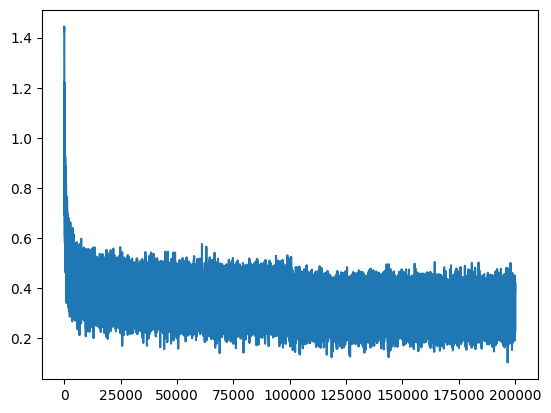

In [21]:
plt.plot(lossi)

In [22]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):    
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.11914324760437
val 2.162384510040283


In [30]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1) # concatenate the vectors
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word



carmah.
ambrilli.
kimri.
rehtlinna.
sane.
mahnen.
deliah.
jaree.
corrisephanaiir.
kaleigh.
ham.
join.
quinton.
lilea.
jamilio.
jerry.
jarynix.
kael.
drudi.
emmedo.


## Weight Initialization 

### Last Layer Initialization

<span style="font-size:18px; font-weight:bold;"> The goal: </span><br><br>
<span style="font-size:15px; "> So we have a tanh layer, that squashed all values between -1 and 1, and then is multiplied by w2+b, for 100 hidden layers, so each output logit for 27, is a result of 100x100, because inner dimensions must match, multiplying normally ditributed values by -1, and 1, with addition grows linearly.<br><br>
    <code>logit = h1*w1 + h2*w2 + h3*w3 + ... + h100*w100</code></span>

    Each h is between -1 and 1 (from tanh). Each w is a random number from a normal distribution with std 1.
    Each individual product h_i * w_i is small — roughly between -1 and 1.
    
    But you're adding 100 of these together. Each term is random — some positive, some negative. They don't perfectly cancel out. The more terms you add, the more the total can drift away from zero.
    The math says: if each term has variance v, then the sum of n terms has variance n * v. So variance grows linearly with the number of terms.
    
    With 100 terms, the standard deviation of the sum is about sqrt(100) = 10. So your logit could easily be +20 or -15, even though each individual piece was small.
    

In [441]:
res = (torch.randn(27)*10)
res.std(), res.shape

(tensor(8.3939), torch.Size([27]))

Imagine the `res` is the logits before it goes for softmax

In [442]:
output = torch.softmax(res, dim=0)

In [476]:
import random
for i in range(3): 
    rand = random.choice((range(27)))
    print(f"probability of {output[rand]:.2f}")
    print(-torch.log(output[rand]))

probability of 0.00
tensor(23.2330)
probability of 0.00
tensor(11.7712)
probability of 0.43
tensor(0.8380)


<b> Because the distribution is more peaked with high standard deviation the probabilities 
    The model will be confidently wrong, because it has initially higher probability without any prior knowledge. Because the probability is dominated by few higher values, and the rest are zero, as shown above, if you run the cell multiple times, you will find we more than 90% of picking a value with zero probability for the correct answer, and that is very bad initialization, because the optimization will be at the initial iterations, is focused on these confidently wrong, while a uniform distibution is guranteed a loss of 3.2 because -log(1/27), because each character is equally likely are equally likely. 

In [486]:
-torch.log(torch.tensor([1/27]))

tensor([3.2958])

<span style="font-size:18px;">
    To summarize having normal values of the layer w2 that is randomly distributed will result in more high values because of the summation of the dot product, which will make the softmax when normalizing to probabilities, is very confident about these values, with very low chance of being correct, so we end up with very bad loss at the start. While having uniform is guaranteed a reasonable loss of 3.2. To achieve this we could scale down w2 by a very small factor like 0.1, which will make all values small. So the dot product for each logit is a small value very close to uniform, which what we want at initialization. 

In [503]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden,                        generator=g) 
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # to achieve uniform distribution
b2 = torch.randn(vocab_size,                      generator=g) * 0 # no bias needed at the start

# do one forward pass
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr[ix])


parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

11897


In [488]:
split_loss('train')
split_loss('val')

train 3.3080811500549316
val 3.308419704437256



<span style="font-size:16px; font-weight:bold;"> Without any optimization we achieve a initially a reasonable good start. The initial loss is much better, and we save few epochs and prevent that hockey loss shape above, because of a bad initialization, that forces the model to shrink all values before optimizing. And we focused on W2 and B2, because these are the last layer, before it goes to softmax, the previous one, is squashed using a tanh layer

### Problem of the First layer initialization that leads to Tanh Saturation

<span style="font-size:16px; font-weight:bold;">
    Second problem comes from <code>W1</code> and <code>B1</code>, because they are also badly initialized. after their dot product with embcat (input) we get also high values because of the product summation that happens between <code>embcat @ w1 + b1</code> so Each row of embcat has 10 columns multiplied by the first neuron with 10 inputs and 100 outputs, so we end up of with 5 standard deviation (there is a mathematical proof). 

In [515]:
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Yb
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
hpreact.std().item()

5.548726558685303

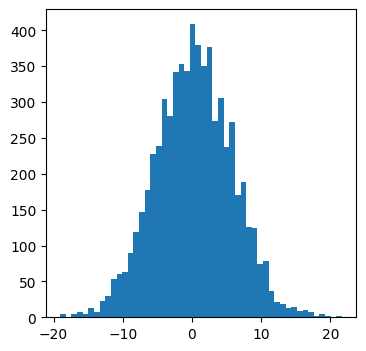

In [516]:
plt.figure(figsize=(4, 4))
plt.hist(hpreact.view(-1).tolist(), 50);

<b> The weights that come out from the tanh layer, if we flatten
the values, then plot the histogram as you can see, it is saturated around -1 and 1. 

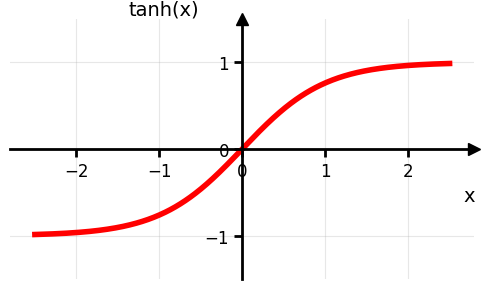

Because tanh for values bigger than 2 or less -2, is to be -1 or 1. So when we have standard deviation of 5. That means a lot of values will be at those regions. Look at code below

In [519]:
hpreact.shape

torch.Size([32, 200])

In [520]:
32 * 200

6400

<span style="font-size:16px;">We have 6400 values total. 

In [535]:
extreme_values = len(hpreact[(hpreact < -2) | (hpreact > 2)]) # value either higher or lower than -2 and 2. 
extreme_values

4577

In [536]:
print(f"{(extreme_values/(32*200)*100):.1f}%")

71.5%


<span style="font-size:16px; font-weight:bold;">So over 70% of values are at the flat tail of tanh, that is called tanh saturation. 

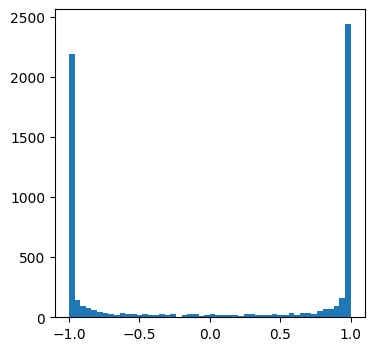

In [538]:
plt.figure(figsize=(4, 4))
plt.hist(h.view(-1).tolist(), 50);

<b> So you get graph like the above. 

<p style="font-size:16px;">This is very alarming because, if you look at the gradient of the tanh $(1 - tanh(x))^{2}$, which means the gradient for most values become <br><br>$$1-1^{2} or 1-(-1)^2$$<br><br> 

    The output gradient is zero or very close values near zero, and this is called vanishing gradient problem. 
    
    A lot of values, don't pass because the gradient becomes zero, so the gradient never flows through to the previous layers, and everything afterward becomes multiplied by zero, because of the chain rule. 
    
    The reason we're able to train a neural network with fatal flaws, because that is essentially a smaller 
    neural network, with a simple problem, however if you get a very deep neural network with 20 to 30 above layers, these problems stack together and the backwardpass can't optimize to reach a low loss because the consequences of each layer is added together, and you can't even train a neural network. In other words the neural network stops learning. 
    

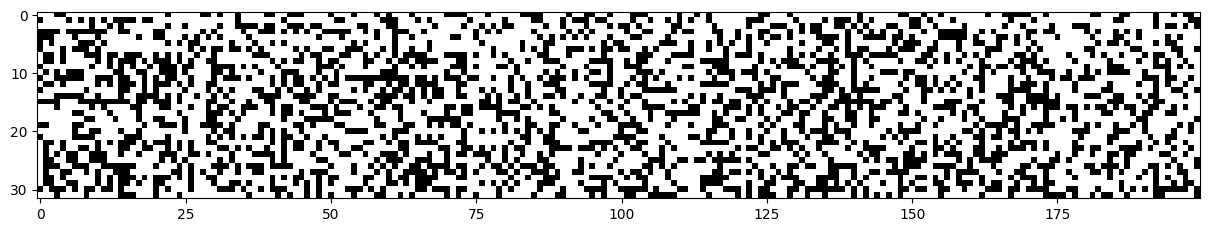

In [74]:
plt.figure(figsize=(15,10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest");

<span style="font-size:16px; font-weight:bold;"> It is 32x200, 32 is the sample rows for the batch, and 200 neurons for each sample. White pixel means the value is at flat tail is either at one or negative one, so if we get a column that is all white, that means it was fed a 32 samples, with each one has extreme tanh values, so we get a dead neuron that never activates. Fortunately we don't, however they are very close columns, that ended up with a batch that all achieved zero gradient, so the neuron will be dead for this batch. 

### W1 and B1 weight's initialization fixes

<span style="font-size:16px;"> Same fix as the previous W2, we will initialize w1 and b1 with very small values. That would make the standard deviation even after multiplication is still around one. So the tanh activation layer balanced. 

<b>Let's try one forward bass

In [107]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2 # to avoid tanh saturation
b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # To add a small entropy, and zero is okay
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # to get a uniform distribution
b2 = torch.randn(vocab_size,                      generator=g) * 0


ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)

# do one forward pass
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr[ix])


parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

In [108]:
split_loss('train')

train 3.305767774581909


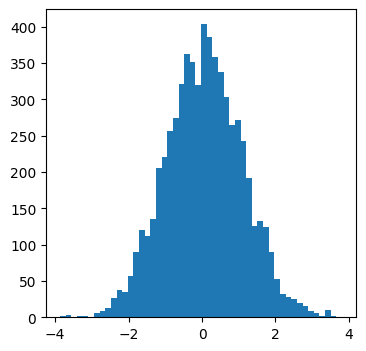

In [109]:
plt.figure(figsize=(4, 4))
plt.hist(hpreact.view(-1).tolist(), 50);

<b> As you can see they have std of 1, which is what we want. 

In [110]:
hpreact.std().item()

1.04727303981781

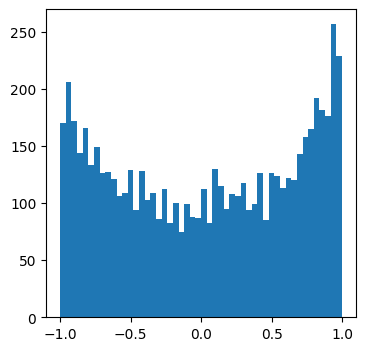

In [111]:
plt.figure(figsize=(4, 4))
plt.hist(h.view(-1).tolist(), 50);

<b> Now we are guranteed that there is no vanshing gradient problem or a dead neuron will occur and the NN can optimize fully, even if very deep neural network. 

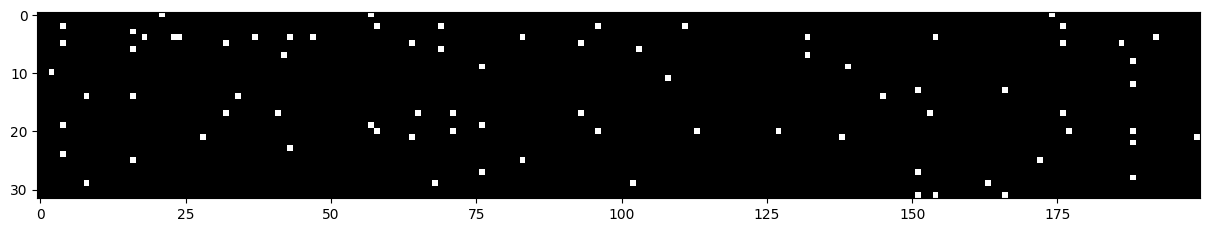

In [112]:
plt.figure(figsize=(15,10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest");

Only small amount of values are activated with tanh. 

```markdown 

original loss
train 2.1245384216308594 val 2.168196439743042

after fix softmax confidently wrong:
train 2.07 val 2.13


after fix tanh layer too saturated at init:
train 2.0355966091156006 val 2.1026785373687744


```

### Principled Approach

<b> There are actually papers that analyzed this and came up with a principled way of initializing neural network.<br>
    [Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification](https://arxiv.org/abs/1502.01852)
    
      However since every activation have different behaviour and values, e.g Tanh, RelU or Sigmoid, etc.
    Each one has it is own principled that is proved mathematically with a good initialization values that will make sure, every activation layer will not get very staturated. 

    

<span style="font-size:15px; font-weight:bold;"> This way is very simple each layer has input and ouput.<br>
    input --> is called fan_in <br>
    output --> is called fan_out.<br><br>
    You simply divide for each layer by $\sqrt{fan\_in}$

x mean: -0.0074, x std: 1.0102
y mean: -0.0015, y std: 1.0153


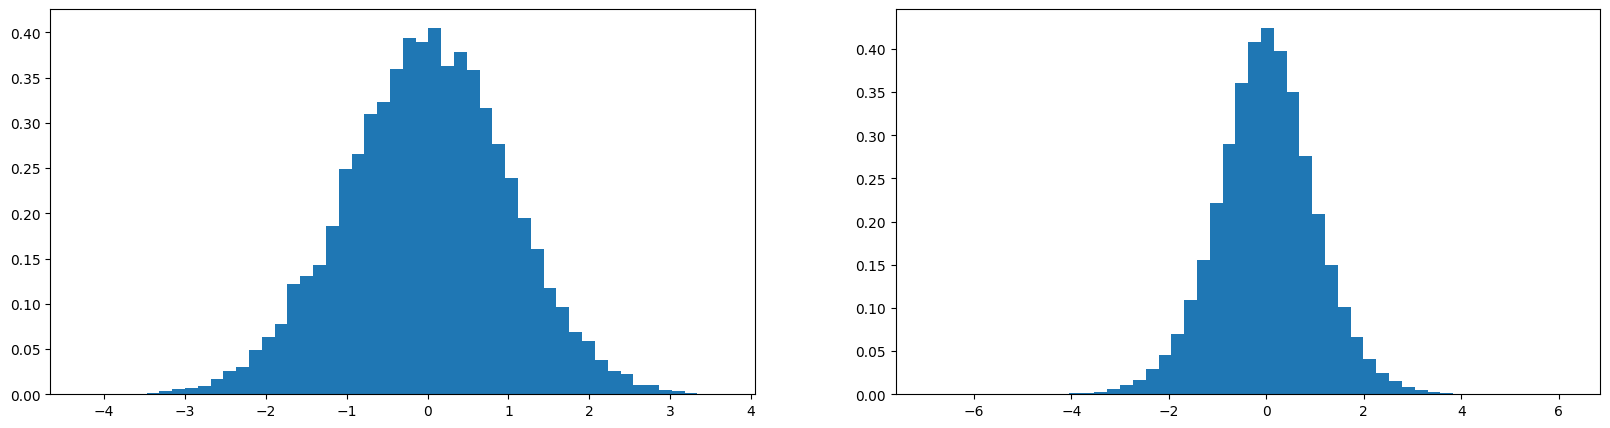

In [116]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w

print(f"x mean: {x.mean().item():.4f}, x std: {x.std(unbiased=False).item():.4f}")
print(f"y mean: {y.mean().item():.4f}, y std: {y.std(unbiased=False).item():.4f}")

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)

plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

plt.show()

    You can try to remove `10**0.5` and see how the standard deviation will change. And will scale to be bigger, based on the number of fan_in. 

<b style="color: red;"> To conclude

<b> The goal is to have Var(w $\cdot$ x) = Var(w), i.e after multiplication we want the variance of result to be the same,and based on variance properties the var will be scaled based on the fan_in(input_dimension) for the layer, to compensate we divide square root of fan_in, that is why the output will remain one, this helps in stability, over many hidden layers or a deep neural network, the variance could change enourmosly, and cause unexpected bugs, like the staturation of tanh, vanishing gradients, or exploding gradients. 

The gain is different from each activation layer to another. if not activation layer, then one only for gain. 
$$
\mathrm{std}(W) = \frac{\text{gain}}{\sqrt{\text{fan_in}}}
$$

For tanh the gain is:

$$
\sigma_W = \frac{\frac{5}{3}}{\sqrt{n_{\text{in}}}}
$$

The whole purpose is the the division over fan_in is to maintain, the weights for Linear Activation, but since, we have tanh activation function which squeezes the weights, we have to compensate by different weights, this is a principle approach, and it was calculated to be 5/3 / fan_in. 

In [541]:
ww = torch.randn((n_embd * block_size, n_hidden), generator=g)
ww.std()

tensor(1.0080)

We want to change that standard deviation to be the above formula. 

In [542]:
w_init = ww * 0.3 
w_init.std()

tensor(0.3024)

So a normally distributed values will have variance or std, that grows or shrinks by the scaler value it is multiplied by. 

Any scaler value multiplied by the weights, will change the std to the scaler value, since std is one. 

To change the std to be: 

$$
\sigma_W = \frac{\frac{5}{3}}{\sqrt{n_{\text{in}}}}
$$


In [543]:
(5/3) / (n_embd * block_size)**0.5 

0.3042903097250923

So we are guranteed that std will 0.3, and when multiplied by x, the standard deviation will not scales to 5, and is to be controlled around one. 

<b>BTW, We did it by 0.2 through trial and observing the tanh saturation, and figured 0.2, was good enough, however this approach is principled and gurantee stable weights across the activation layer, also is fixed, we don't have to try around to find what works, also it is ready made in torch.nn.init.kaiming_normal_().
[torch.nn.init — PyTorch 2.10 documentation](https://docs.pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_normal_)

### Batch Normalization

    It is easy to go into details, and forget why all of this matters, the whole purpose of this notebook, is to achieve stable training over deep neural network, and that require two things, one stable weights, and stable gradients i.e after all this multiplication and addition and non-linear activation functions, at least at the early stages, we don't want two things, one any activation function to be too activated, like tanh saturation or sigmoid, and also for RelU, and we don't want gradient unstability, like vanishing or exploding, so we have two focus on forward passes that the weights is normally distributed. 
    
    If you considered Zero initlization for weights also creates a symmetry problem, because all the weights get the same gradient, which is the same as one neuron. 

    So by initializing the weights through kaiming, or xavier is good.However there we more important approaches that made *initialization techniques matter less*, and the first introduced is batch normalization that was introduced in 2015, and then followed by many techniques like layer normalization, also RMS NORM or group normalization, all of these goal is the same, to have stable training for neural networks.

<b> Batch Normalization whole idea is to literally standardize the weights before they go into activate, by subtracting mean and dividing by the std. Because we want the tanh activation not too much and we get 1's and -1's, so gradients don't follow because we get locally zero gradient, which kills all previous layers, that flow through it, or they never activate at all, we want it in the middle mostly staturated around zero mean and std of 1. 

Here is an example for demonstration

**Your input X is (3 samples, 3 features):**
```
X = [1 1 2]    ← sample 1
    [2 2 3]    ← sample 2
    [3 4 5]    ← sample 3
```

**Your weights W are (3 inputs, 4 neurons):**
```
W = [0.5 0.8 1.1 0.1]
    [1.2 0.3 0.6 0.9]
    [0.3 0.2 0.3 0.5]
```

Each **column** is all the weights for one neuron.

**Now the result of X @ W is (3, 4):**

Each **row** in the result corresponds to one **sample**. And each **column** in the result corresponds to one neuron's output across all samples.

So result[0, :] = sample 1 passed through all 4 neurons.
And result[:, 0] = all 3 samples passed through neuron 1.

Let's verify with sample 1, neuron 1:

`(1 × 0.5) + (1 × 1.2) + (2 × 0.3) = 0.5 + 1.2 + 0.6 = 2.3`

That gives you position `result[0, 0]` — **row 0** (sample 1), **column 0** (neuron 1).

So when BatchNorm normalizes over dim=0, it's going down each **column** — computing the mean and variance of each neuron's output across all samples. stabilizing each neuron's output distribution.

In [144]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # To add a small entropy, and zero is okay
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0


bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) 

for p in parameters:
    p.requires_grad = True

12297


```
normalized hpreact shape:  (32, 200)  ←  32 samples, 200 neurons
            bngain shape:  (1, 200)   ←  one scale per neuron
            bnbias shape:  (1, 200)   ←  one shift per neuron

they broadcast per neuron, so the NN have it is own distribution, and different std. 
So that the NN can control each neuron distribution, or make it wider or narrower,
to move it around with bias, left and right. So each neuron have it is own distribution 
and the NN learns to have good representations per neuron.

output = gamma * normalized + beta
```


In [146]:
max_steps= 200000
batch_size = 32
lossi = []


for i in range(200000):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  
    # forward pass
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2 # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()


    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track_stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        
    lossi.append(loss.log10().item())



      0/ 200000: 3.3100
  10000/ 200000: 2.3046
  20000/ 200000: 2.1078
  30000/ 200000: 2.3260
  40000/ 200000: 2.5696
  50000/ 200000: 2.3081
  60000/ 200000: 2.2972
  70000/ 200000: 1.8720
  80000/ 200000: 2.1814
  90000/ 200000: 2.2426
 100000/ 200000: 2.3885
 110000/ 200000: 1.8758
 120000/ 200000: 2.3901
 130000/ 200000: 2.2642
 140000/ 200000: 1.9770
 150000/ 200000: 2.3351
 160000/ 200000: 2.1031
 170000/ 200000: 2.1136
 180000/ 200000: 2.2506
 190000/ 200000: 1.7381


In [147]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):    
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # do the same as training
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias 
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


train 2.065624713897705
val 2.1104793548583984


In [148]:
split_loss('train')
split_loss('val')


train 2.065624713897705
val 2.1104793548583984


#### Side Effect of batch Normalization

<p style="font-size:15px"> The main side effect of batch normalization that it introduces regularization, due to this line:<br> <code>hpreact = bngain x (hpreact - hpreact.mean() / hpreact.std() + bnbias </code> <br> it introduces some <b>jitter</b> to each sample, because the sample is dependent on the randomly selected batch, so it introduces coupling effect between samples and a batch, while aslo prevent the model from overfitting, because there is randomness of values that is being added. 

<b>Another Side Effect</b>: <br> That we can't forward a single example, because the bmean and bstd, is being calculated over a batch, so we have two options, one calculate <b>bnmean_running</b> and <b>bnstd_running</b> over all the batches or calculate it once on the entire dataset, both will be approximately the same. </p>

#### First Way of Mean over entire dataset

In [216]:
# calibrate the batch norm at the end of training
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)


In [206]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):    
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    # do the same as training
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias 
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

#### 2nd Way: bnmean_running and bnstd_Running

<b>Also we don't need b1, because after subtracting from mean in each batch, the data is centered around zero, so the bias is useless, and that is why we have bnbias to adjust for it </b>

In [207]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
# b1 = torch.randn(n_hidden,                        generator=g) 
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0


bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))


bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) 

for p in parameters:
    p.requires_grad = True

12097


In [208]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):    
    x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 
    # do the same as training
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias 
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

In [212]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hpreact = embcat @ W1 # hidden layer pre-activation
    
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad(): #momentum 0.001 because of small size 
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -------------------------------------------------------------
    
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
  

      0/ 200000: 3.2856
  10000/ 200000: 2.1340
  20000/ 200000: 2.1373
  30000/ 200000: 2.2285
  40000/ 200000: 2.0133
  50000/ 200000: 1.7307
  60000/ 200000: 2.2741
  70000/ 200000: 2.2340
  80000/ 200000: 2.3828
  90000/ 200000: 2.0722
 100000/ 200000: 2.2072
 110000/ 200000: 2.1703
 120000/ 200000: 2.2788
 130000/ 200000: 1.8803
 140000/ 200000: 1.7875
 150000/ 200000: 2.1805
 160000/ 200000: 1.9339
 170000/ 200000: 1.9587
 180000/ 200000: 2.1038
 190000/ 200000: 2.0363


In [218]:
(torch.abs(bnmean - bnmean_running) < 0.1).all()

tensor(True)

In [217]:
(torch.abs(bnstd - bnstd_running) < 0.1).all()

tensor(True)

In [219]:
split_loss('train')
split_loss('val')

train 2.0657238960266113
val 2.109696865081787


<span style="font-size:18px; font-weight:bold;">Conclusion</span>

    Linear → Normalize → Nonlinearity
    
    More concretely:
    A linear transformation (fully connected layer, convolution, attention projection)
    A normalization step (BatchNorm, LayerNorm, GroupNorm, RMSNorm)
    A nonlinear activation (ReLU, GELU, SiLU/Swish, tanh)

     This "sandwich" pattern shows up everywhere — in ResNets (Conv → BN → ReLU), in Transformers (linear                projection → LayerNorm → GELU in the MLP block), in older architectures, and in newer ones. The specific            choices within each slot change over time (BatchNorm gave way to LayerNorm, ReLU gave way to GELU/SiLU), but          the structural pattern itself is remarkably persistent.
     
    The intuition is each piece has a distinct role: the linear layer does the learnable transformation and mixes information, the normalization controls the scale/distribution of activations (keeping gradients healthy), and the nonlinearity introduces the expressiveness that lets the network approximate complex functions. Without any one of these, training either becomes unstable or the network loses representational power.

## Building MLP in Classes like Pytorch

<b>The classes we create here are the same API as nn.Module in PyTorch</b>

In [561]:
class Linear: 
    def __init__(self, fan_in, fan_out, bias=True): 
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
                                
    def __call__(self, x): 
        self.out = x @ self.weight 
        if self.bias is not None: 
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([self.bias] if not self.bias is not None else [])

     
    def __repr__(self): 
        if self.bias is not None: 
            return f"Layer({self.weight.shape[0]}, {self.weight.shape[1]}), Bias({self.bias.shape[0]})"
        else: 
            return f"Layer({self.weight.shape[0]}, {self.weight.shape[1]})"
        

In [562]:
class BatchNorm1d: 
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps # to avoid division by zero
        self.momentum = momentum
        self.Training = True
        
        self.gamma = torch.ones(dim) #bngain
        self.beta = torch.zeros(dim)  #bnbias
        
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
        
    def __call__(self, x): 
        if self.training: 
            mean = x.mean(0, keepdims=True) # batch mean
            var  = x.var(0, keepdims=True) # batch variance
            self.out = self.gamma * ( (x-mean) / (torch.sqrt(var+self.eps)) )  + self.beta
            
            with torch.no_grad(): 
                self.running_mean = ((1-momentum) * self.running_mean) + (momentum * self.mean)
                self.running_var = ((1-momentum) * self.running_var) + (momentum * self.var)
                
            return self.out
        
        else: 
            self.out = self.gamma * ( (x-self.running_mean) / (torch.sqrt(self.running_var+self.eps)) )  + self.beta
            return self.out
        
    def parameters(self): 
        return [self.gamma, self.beta]
    
    def __repr__(self): 
        return f"BatchNorm1d({self.gamma.shape[0]})"
           

In [563]:
BatchNorm1d(10)

BatchNorm1d(10)

In [564]:
class Tanh:         
    def __call__(self, x): 
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self): 
        return []
    
    def __repr__(self): 
        return "Tanh()"

### Building Deep Neural Network

In [608]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
vocab_size = len(itos)
block_size = 3

In [609]:
vocab_size # output characters

27

In [631]:
C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden), Tanh(), 
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size),
]

In [632]:
for i in range(len(layers)):
    print(layers[i])
    if isinstance(layers[i], Tanh) :
        print("-----")

Layer(30, 100), Bias(100)
Tanh()
-----
Layer(100, 100), Bias(100)
Tanh()
-----
Layer(100, 100), Bias(100)
Tanh()
-----
Layer(100, 100), Bias(100)
Tanh()
-----
Layer(100, 100), Bias(100)
Tanh()
-----
Layer(100, 27), Bias(27)


```
We have a groups of 
Linear | Nonlinearity 
Stacked up together
```

In [633]:
with torch.no_grad(): 
    
    layers[-1].weight *= 0.1 
    # make last layer less confident, so we achive unifrom distribution in early stages
    
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # because of tanh


parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

45970


In [675]:
C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden), Tanh(), 
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size),
]


with torch.no_grad(): 
    
    layers[-1].weight *= 0.1 
    # make last layer less confident, so we achive unifrom distribution in early stages
    
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3 # because of tanh


parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []


for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000: 
        break

45970
      0/ 200000: 3.2763


<span style="font-size:16px;"> Single forward and backward pass

layer 1 Tanh(): mean +0.02, std 0.80, saturated: 29.62%
layer 3 Tanh(): mean -0.00, std 0.72, saturated: 12.81%
layer 5 Tanh(): mean +0.01, std 0.73, saturated: 13.47%
layer 7 Tanh(): mean +0.04, std 0.74, saturated: 11.88%
layer 9 Tanh(): mean -0.05, std 0.72, saturated: 11.88%


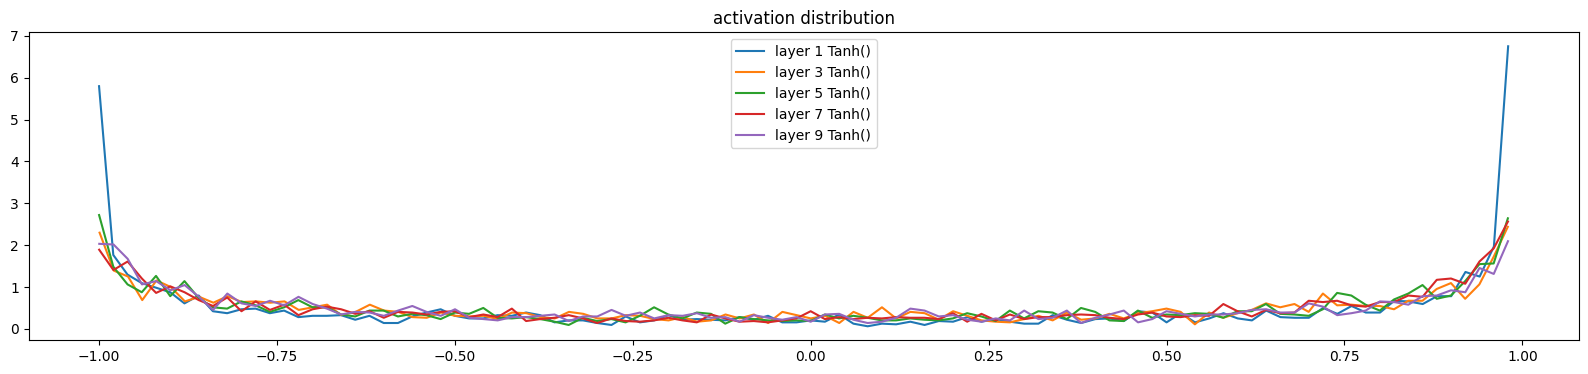

In [676]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot

legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d %5s: mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer}')
        
plt.legend(legends);
plt.title('activation distribution');


As you can see, the start is good with 20% saturation, and then it shrinks down and stabilize, with std around 0.65. In the initialization in the class linear we divided by <code>fan_in**0.5</code>. Then later we multiplied by gain of 5/3. 

<b> However, if we removed 5/3 and made the gain 1, you could remove it and rerun the code, but you would find the result as here. 

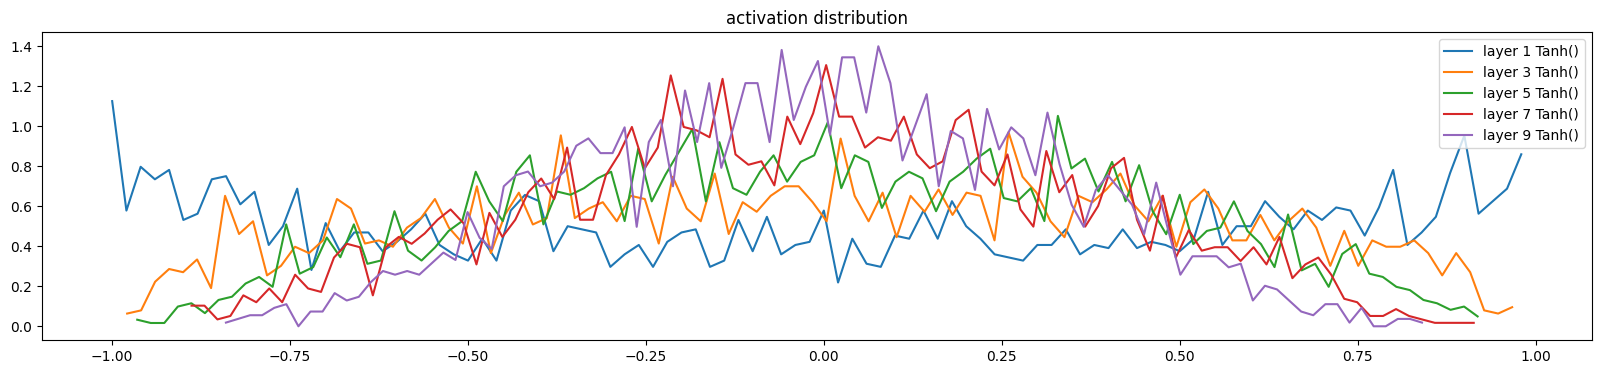

```
layer 1 Tanh(): mean -0.00, std 0.63, saturated: 5.16%

layer 3 Tanh(): mean +0.01, std 0.49, saturated: 0.25%

layer 5 Tanh(): mean +0.01, std 0.42, saturated: 0.00%

layer 7 Tanh(): mean -0.01, std 0.37, saturated: 0.00%

layer 9 Tanh(): mean -0.00, std 0.32, saturated: 0.00%
```

And the reason for that is obvious, while dividing by square root of fan_in, keeps the variance at 1, having many layers with tanh, will squash values, into lower and lower values, as we get more deep layers, that is why 5/3, we need some number bigger than one, to balance that shrinkage that happens because of tanh, to maintain balance. 

layer 1 Tanh(): mean +0.000140, std 3.024028e-03
layer 3 Tanh(): mean +0.000026, std 2.834625e-03
layer 5 Tanh(): mean -0.000028, std 2.753736e-03
layer 7 Tanh(): mean +0.000026, std 2.723388e-03
layer 9 Tanh(): mean -0.000025, std 2.229562e-03


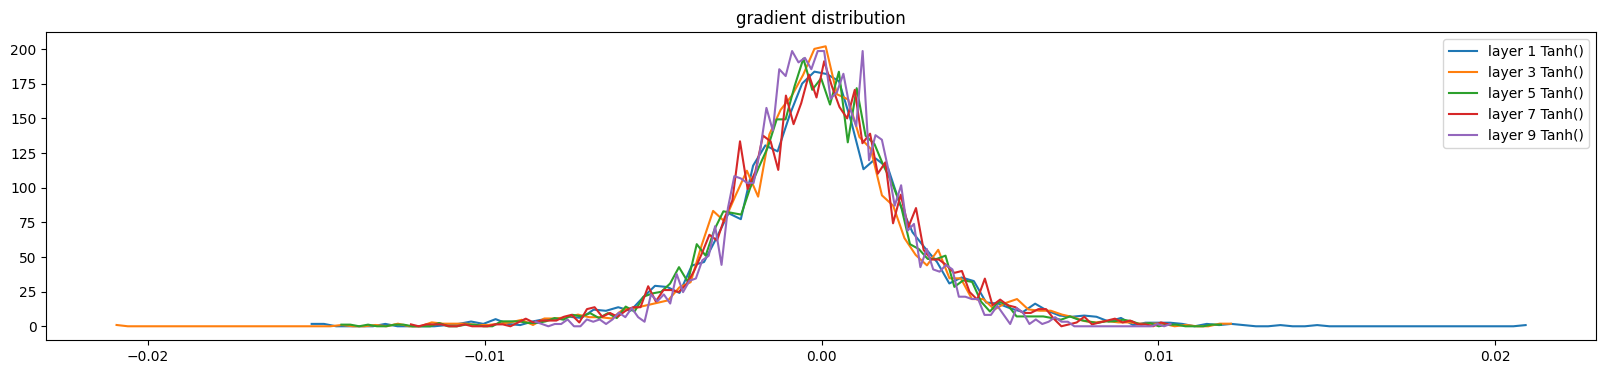

In [677]:
# visualize histograms of gradients
plt.figure(figsize=(20, 4)) # width and height of the plot

legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad # gradients
        print('layer %d %5s: mean %+f, std %e' % (i, layer, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} {layer}')
        
plt.legend(legends);
plt.title('gradient distribution');


weight   (27, 10) | mean -0.000877 | std 9.380335e-03 | grad:data ratio 8.702108e-03
weight  (30, 100) | mean +0.000364 | std 9.860686e-03 | grad:data ratio 3.163523e-02
weight (100, 100) | mean -0.000113 | std 7.600361e-03 | grad:data ratio 4.508995e-02
weight (100, 100) | mean +0.000031 | std 6.625425e-03 | grad:data ratio 3.930312e-02
weight (100, 100) | mean -0.000041 | std 6.273154e-03 | grad:data ratio 3.747154e-02
weight (100, 100) | mean -0.000022 | std 5.249301e-03 | grad:data ratio 3.121107e-02
weight  (100, 27) | mean +0.000000 | std 2.158843e-02 | grad:data ratio 3.062596e-01


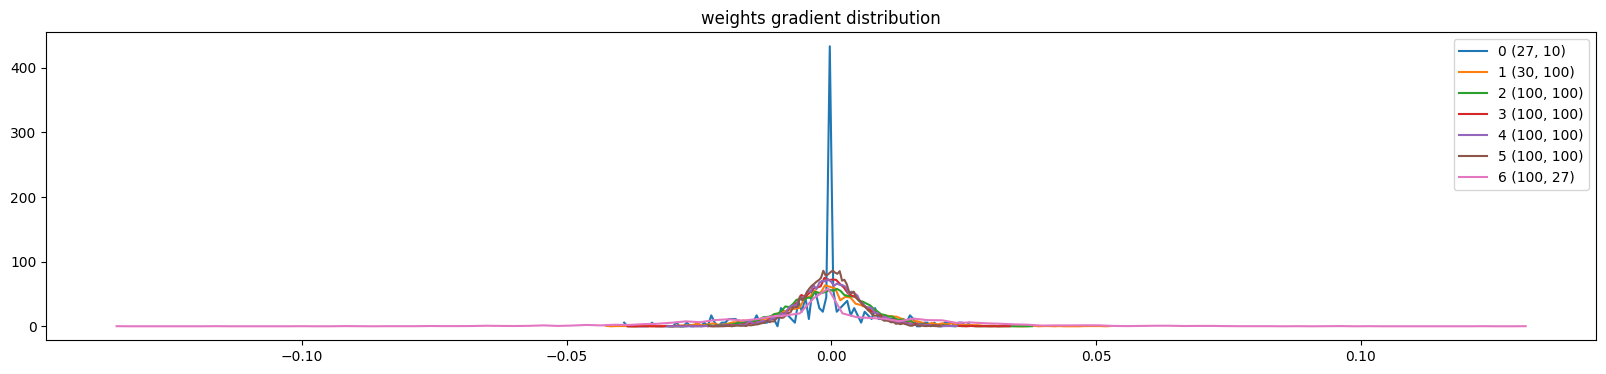

In [678]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



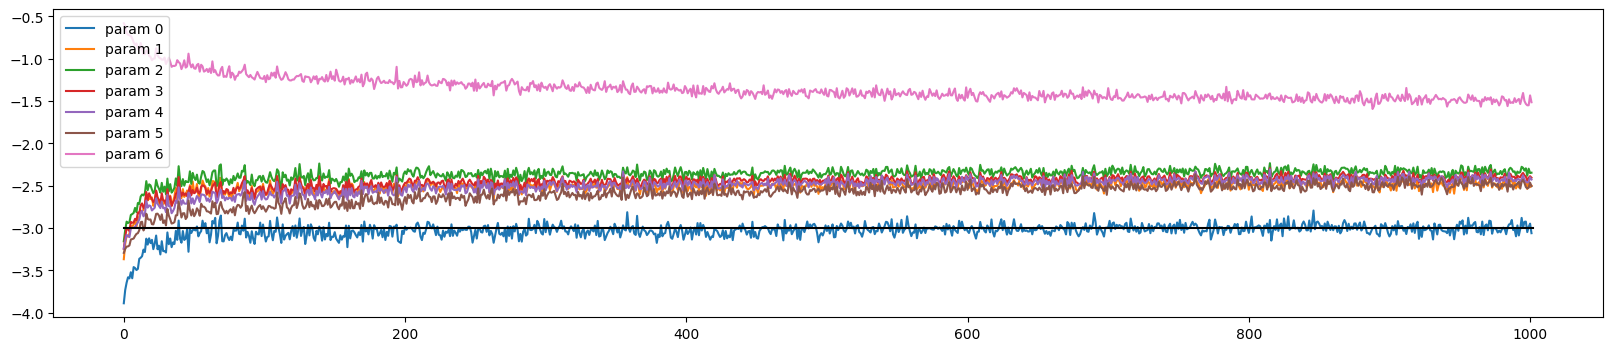

In [679]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

### Apendix 

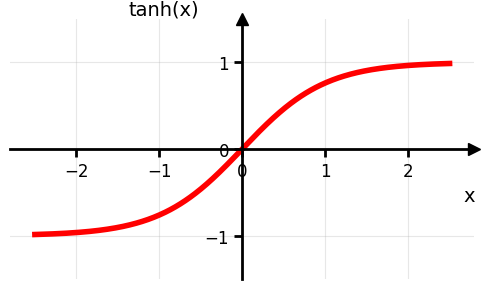

In [587]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2.5, 2.5, 500)
y = np.tanh(x)

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(x, y, color='red', linewidth=4)

ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-1.5, 1.5)
ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([-1, 0, 1])

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.plot(1, 0, '>k', markersize=8, transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, '^k', markersize=8, transform=ax.get_xaxis_transform(), clip_on=False)

ax.set_xlabel('x', fontsize=14, loc='right')
ax.set_ylabel('tanh(x)', fontsize=14, loc='top', rotation=0)

ax.tick_params(labelsize=12, width=2, length=6)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tanh_plot.png', dpi=150)
plt.show()